# Real-Time Emotion Detector — Google Colab Walkthrough

**Lumexa Computer Vision Track portfolio project**

Detect faces in a photo with OpenCV's Haar Cascade classifier, then classify each
detected face's visible expression pattern into one of 7 categories (Angry, Disgust,
Fear, Happy, Neutral, Sad, Surprise) using a small pretrained Convolutional Neural
Network (CNN).

This notebook is fully self-contained and works with **Runtime → Run all** — no
webcam, no API key, and no dataset download or model training required.

**Why this differs from the original local project:** the original version of this
project ran as a live webcam application (`cv2.VideoCapture` + `cv2.imshow` in a loop)
and expected *you* to train your own CNN on the FER2013 dataset before it could
classify anything. Neither of those works in Google Colab: there is no local camera
device or GUI window here, and requiring students to source and train a dataset just
to see the pipeline work is a poor fit for a walkthrough notebook. This notebook keeps
the same two-stage pipeline and the same responsible-use framing, but:

- swaps the live webcam loop for **static photos**, displayed with `matplotlib`
  (`cv2.imshow` does not work in Colab),
- swaps "train your own model" for a small **pretrained** CNN downloaded automatically
  the first time you run this notebook (see Step 2 for exactly which model and why),
- adds an optional cell at the end where you can upload your own photo.

## Important Disclaimer — Please Read First

**This project classifies visible facial expression patterns. It does not measure,
detect, or know a person's true internal emotions.**

A neural network trained on labeled photos learns statistical correlations between
facial muscle configurations (mouth shape, eyebrow position, eye openness, etc.) and
human-assigned labels like "happy" or "sad." It has no access to what a person
actually feels — a person can smile while anxious, or look neutral while delighted.
The confidence score this notebook displays reflects how closely a detected face's
pattern resembles the model's training examples, not a certainty about reality.

This system can also be **biased and inaccurate**, especially for faces, lighting
conditions, ages, and expressions underrepresented in whatever dataset trained the
model. Do not use this project (or any derivative of it) to make real decisions about
real people — hiring, discipline, grading, medical judgments, or anything with
consequences — without qualified human review and much more rigorous, audited
validation than a classroom project provides. Always disclose to anyone on camera (or
in a photo you analyze) that expression analysis is running, and never analyze or
store images of people without their knowledge and consent.

## Learning Objectives

- Understand how face detection (Haar Cascades) and expression classification (CNN)
  combine into one pipeline.
- Learn how to preprocess a cropped face image (grayscale, resize, normalize) to match
  a neural network's expected input.
- Practice structuring a pipeline with clean separation between detection,
  classification, and rendering.
- Practice communicating AI capabilities and limitations honestly to end users.

## Setup

`numpy`, `matplotlib`, and `tensorflow` are already preinstalled in Google Colab.
`opencv-python-headless` is usually present too, but we pin it explicitly to a 4.x
release: the newer **OpenCV 5.0** wheel removed the bundled Haar Cascade XML data
files from the Python package entirely (`cv2.data.haarcascades` exists but is empty),
which silently breaks face detection. Pinning to a known-good 4.x version guarantees
the cascade file this notebook needs is actually present.

In [1]:
%pip install -q "opencv-python-headless==4.10.0.84"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("OpenCV version:", cv2.__version__)
print("TensorFlow version:", tf.__version__)

I0000 00:00:1789672673.999452    2941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789672674.042235    2941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789672675.288627    2941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


OpenCV version: 4.10.0
TensorFlow version: 2.21.0


## Step 1: Face Detection (Haar Cascade)

We use OpenCV's classic Haar Cascade classifier for face detection, exactly like the
original project. It ships inside `opencv-python` itself (`cv2.data.haarcascades`), so
no download is needed for this stage. It's fast and simple, but — as the original
project's README notes — it's an older method that can miss faces at an angle or in
poor lighting; a modern DNN-based face detector would do better, at the cost of more
complexity.

In [3]:
FACE_SCALE_FACTOR = 1.1
FACE_MIN_NEIGHBORS = 5
FACE_MIN_SIZE = (60, 60)

face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(face_cascade_path)
assert not face_cascade.empty(), "Failed to load Haar Cascade -- check the OpenCV installation."


def detect_faces(frame_bgr):
    """Detects faces in a BGR image. Returns a list of (x, y, w, h) boxes."""
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=FACE_SCALE_FACTOR,
        minNeighbors=FACE_MIN_NEIGHBORS,
        minSize=FACE_MIN_SIZE,
    )
    return [tuple(int(v) for v in f) for f in faces]


print("Face detector ready (Haar Cascade frontal face default).")

Face detector ready (Haar Cascade frontal face default).


## Step 2: Expression Classification Model

The original project shipped **no trained model and no dataset** — you were expected
to train your own CNN on FER2013 (or a similar dataset) before the app could classify
anything. That's not workable for a notebook meant to run end-to-end with "Run all",
so this notebook uses a **pretrained** model instead. No training, no dataset
download, and no API key are required.

**What we investigated first:** the task called for evaluating the `fer` PyPI package
(`pip install fer`), which wraps a pretrained Keras CNN for exactly these 7 FER
emotions. In practice, installing it in a clean environment fails: `fer` pins
`moviepy<2.0`, an old release whose build no longer works with current `setuptools`,
and even when that's worked around, `fer` drags in heavy, unrelated dependencies
(`facenet-pytorch`, `ffmpeg-python`, `opencv-contrib-python`) just to classify static
images. That's fragile for a teaching notebook that needs to "just work" on Runtime →
Run all.

**What we use instead:** the same *type* of well-known pretrained FER2013 model,
fetched directly — no extra package needed. We download
`fer2013_mini_XCEPTION.102-0.66.hdf5`, a small (~230K-parameter, ~850KB), widely used,
MIT-licensed Keras model from
[oarriaga/face_classification](https://github.com/oarriaga/face_classification) (this
is in fact the same underlying model family the `fer` package itself wraps). It takes
a single 64×64 grayscale face crop and outputs a 7-way softmax over:
`["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]` — note this
source model's own label order, which we use as-is below, differs from the ordering
listed in this project's original README/config (`Angry, Disgust, Fear, Happy,
Neutral, Sad, Surprise`); getting label order right matters far more than which
ordering convention was originally chosen, so we use the trained model's actual order.

As in the original project, predictions below the confidence threshold (0.35) are
shown as `"Uncertain"` rather than a falsely confident label.

In [4]:
MODEL_URL = (
    "https://raw.githubusercontent.com/oarriaga/face_classification/master/"
    "trained_models/emotion_models/fer2013_mini_XCEPTION.102-0.66.hdf5"
)

model_path = tf.keras.utils.get_file(
    fname="fer2013_mini_XCEPTION.h5",
    origin=MODEL_URL,
    cache_subdir="emotion_detector_models",
)

emotion_model = tf.keras.models.load_model(model_path, compile=False)

# This is the trained model's own class order -- do not reorder these.
EMOTION_LABELS = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]
EMOTION_INPUT_SIZE = emotion_model.input_shape[1]  # 64
EMOTION_CONFIDENCE_THRESHOLD = 0.35  # below this, label is shown as "Uncertain"

print("Emotion model loaded from:", model_path)
print("Input shape:", emotion_model.input_shape, " Output shape:", emotion_model.output_shape)

     0/872856 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

442368/872856 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

872856/872856 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Emotion model loaded from: /root/.keras/emotion_detector_models/fer2013_mini_XCEPTION.h5
Input shape: (None, 64, 64, 1)  Output shape: (None, 7)


## Step 3: Preprocessing and Classification

Just like the original `emotion_model.py`'s `preprocess()`, each detected face crop is
converted to grayscale, resized, and normalized before being handed to the model. This
particular model was trained with pixel values scaled to **[-1, 1]** (not [0, 1]), so
the normalization step below matches that.

In [5]:
def preprocess_face(face_crop_bgr):
    gray = cv2.cvtColor(face_crop_bgr, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(
        gray, (EMOTION_INPUT_SIZE, EMOTION_INPUT_SIZE), interpolation=cv2.INTER_AREA
    )
    normalized = resized.astype("float32") / 255.0
    normalized = (normalized - 0.5) * 2.0  # scale to [-1, 1] to match this model's training
    return normalized.reshape(1, EMOTION_INPUT_SIZE, EMOTION_INPUT_SIZE, 1)


def classify_emotion(face_crop_bgr):
    """Returns (label, confidence) for a single BGR face crop.

    If the top confidence is below EMOTION_CONFIDENCE_THRESHOLD, returns
    ("Uncertain", confidence) instead of forcing a possibly misleading label.
    """
    tensor = preprocess_face(face_crop_bgr)
    predictions = emotion_model.predict(tensor, verbose=0)[0]
    best_index = int(np.argmax(predictions))
    confidence = float(predictions[best_index])

    if confidence < EMOTION_CONFIDENCE_THRESHOLD:
        return "Uncertain", confidence

    return EMOTION_LABELS[best_index].capitalize(), confidence


print("Preprocessing and classification functions ready.")

Preprocessing and classification functions ready.


## Step 4: The Full Pipeline

This mirrors the original `main.py`'s `process_frame()`: detect every face in an
image, then classify each detected crop independently.

In [6]:
def analyze_image(frame_bgr):
    """Runs face detection + expression classification on one BGR image.

    Returns a list of dicts: {"box": (x, y, w, h), "label": str, "confidence": float}
    """
    faces = detect_faces(frame_bgr)
    detections = []
    for (x, y, w, h) in faces:
        face_crop = frame_bgr[y:y + h, x:x + w]
        label, confidence = classify_emotion(face_crop)
        detections.append({"box": (x, y, w, h), "label": label, "confidence": confidence})
    return detections


print("Pipeline function ready.")

Pipeline function ready.


## Step 5: Rendering Results

The original project drew boxes and labels with `cv2.rectangle`/`cv2.putText` and
displayed them live with `cv2.imshow` in a loop. `cv2.imshow` does not work in Colab
(there's no local GUI window), so instead we draw with the same OpenCV drawing
functions onto a copy of the image, convert from OpenCV's BGR channel order to RGB,
and display it with `matplotlib`.

In [7]:
BOX_COLOR = (0, 255, 0)          # RGB green -- confident prediction
UNCERTAIN_COLOR = (255, 140, 0)  # RGB orange -- low-confidence prediction


def draw_detections(frame_bgr, detections):
    annotated = frame_bgr.copy()
    for det in detections:
        x, y, w, h = det["box"]
        label, confidence = det["label"], det["confidence"]
        # cv2 drawing functions on a BGR image expect BGR color tuples
        color_rgb = UNCERTAIN_COLOR if label == "Uncertain" else BOX_COLOR
        color_bgr = color_rgb[::-1]

        cv2.rectangle(annotated, (x, y), (x + w, y + h), color_bgr, 3)
        caption = f"{label} ({confidence * 100:.0f}%)"
        text_y = max(25, y - 12)
        cv2.putText(
            annotated, caption, (x, text_y),
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, color_bgr, 2, cv2.LINE_AA,
        )
    return annotated


def show_image(frame_bgr, title=""):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


print("Rendering functions ready.")

Rendering functions ready.


## Step 6: Automatic Demo (no interaction needed)

This section runs entirely on its own under **Runtime → Run all** — nothing to click,
type, or upload. We download a handful of real, public, freely licensed sample photos
(from the same `face_classification` project's own test image plus a few classic
face-detection example photos from `dlib`'s example gallery) and run the full
detect → classify → render pipeline on each one.

Haar Cascade sometimes misses a face — that's a real limitation of this fast, older
detection method (see the original README's "Common Problems" notes), not a bug in
this notebook, and it's fine if one of the sample photos below shows no boxes.

In [8]:
SAMPLE_IMAGE_URLS = [
    ("obama.jpg", "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg"),
    ("group_1.jpg", "https://raw.githubusercontent.com/davisking/dlib/master/examples/faces/2008_001322.jpg"),
    ("group_2.jpg", "https://raw.githubusercontent.com/davisking/dlib/master/examples/faces/2008_002079.jpg"),
    ("group_3.jpg", "https://raw.githubusercontent.com/davisking/dlib/master/examples/faces/2009_004587.jpg"),
]

sample_dir = "sample_faces"
os.makedirs(sample_dir, exist_ok=True)

sample_paths = []
for filename, url in SAMPLE_IMAGE_URLS:
    path = os.path.join(sample_dir, filename)
    if not os.path.isfile(path):
        urllib.request.urlretrieve(url, path)
    sample_paths.append(path)

print(f"Downloaded {len(sample_paths)} sample photos to '{sample_dir}/'.")

Downloaded 4 sample photos to 'sample_faces/'.


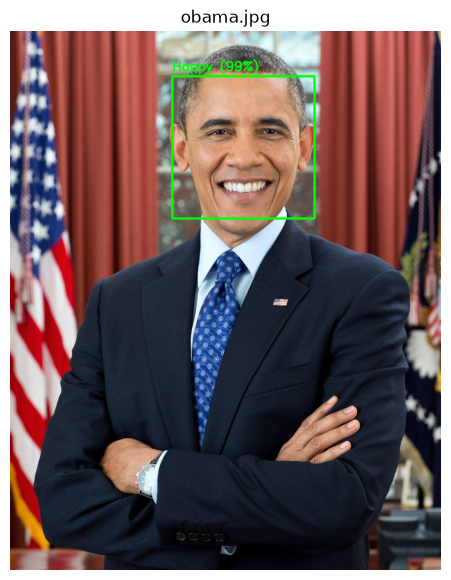

  obama.jpg: Happy (99.4%) at box (342, 95, 300, 300)


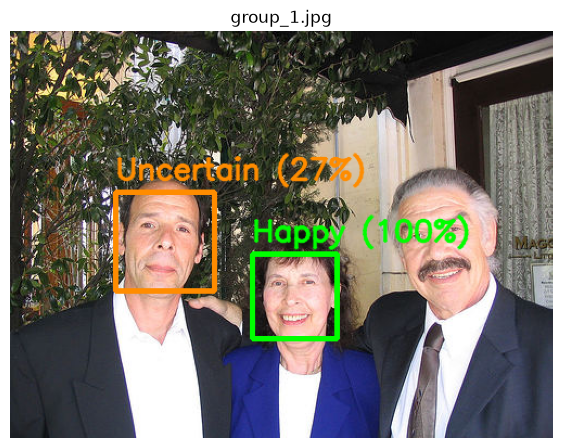

  group_1.jpg: Happy (99.9%) at box (223, 205, 78, 78)
  group_1.jpg: Uncertain (26.9%) at box (97, 148, 91, 91)


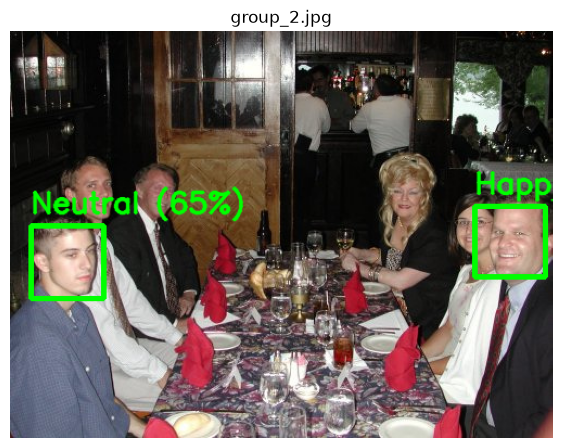

  group_2.jpg: Happy (99.8%) at box (428, 161, 65, 65)
  group_2.jpg: Neutral (64.9%) at box (19, 179, 67, 67)


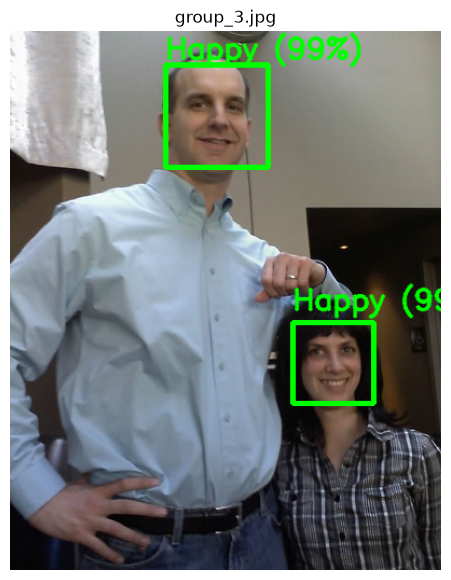

  group_3.jpg: Happy (99.3%) at box (144, 31, 95, 95)
  group_3.jpg: Happy (99.2%) at box (262, 270, 75, 75)


In [9]:
for path in sample_paths:
    frame = cv2.imread(path)
    if frame is None:
        print(f"Could not read {path} -- skipping.")
        continue

    detections = analyze_image(frame)
    annotated = draw_detections(frame, detections)
    show_image(annotated, title=os.path.basename(path))

    if detections:
        for det in detections:
            print(f"  {os.path.basename(path)}: {det['label']} ({det['confidence'] * 100:.1f}%) at box {det['box']}")
    else:
        print(f"  {os.path.basename(path)}: no faces detected (a known Haar Cascade limitation).")

## Optional — try it yourself

Everything above already ran automatically. This last cell is **optional**: if you're
running this notebook inside Google Colab, it lets you upload your own photo and see
it analyzed. It uses `google.colab.files.upload()` — a one-time upload dialog, not a
live webcam — and simply does nothing (with a short message) if it's run outside
Colab, so it never blocks or breaks a full "Run all".

Remember the disclaimer above: only upload photos of yourself or people who have
consented, and remember the predicted label is a pattern-match to training data, not a
measurement of how anyone actually feels.

In [10]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Upload a photo with one or more visible faces (jpg/png).")
    uploaded = files.upload()
    for filename in uploaded.keys():
        frame = cv2.imread(filename)
        if frame is None:
            print(f"Could not read '{filename}' as an image.")
            continue
        detections = analyze_image(frame)
        annotated = draw_detections(frame, detections)
        show_image(annotated, title=filename)
        if not detections:
            print(f"  {filename}: no faces detected.")
else:
    print(
        "This cell uses google.colab.files.upload() and only runs inside Google "
        "Colab. Open this notebook in Colab and re-run this cell to try it with "
        "your own photo."
    )

This cell uses google.colab.files.upload() and only runs inside Google Colab. Open this notebook in Colab and re-run this cell to try it with your own photo.


## Extensions

Ideas if you want to take this further, carried over from the original project:

- Swap the Haar Cascade for a more modern DNN-based face detector (e.g., OpenCV's
  bundled `FaceDetectorYN`) for better accuracy across angles and lighting.
- Log expression predictions across a batch of photos to a table and chart the
  distribution of predicted labels.
- Add face-alignment (eyes-level cropping) before classification to improve accuracy.
- Try fine-tuning this model, or a model you train yourself, on a labeled dataset such
  as FER2013 if you want to compare against the pretrained one used here.

And once more: this notebook classifies visible expression **patterns**, not true
feelings. Use it to learn about computer vision pipelines, not to make real judgments
about real people.